In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Data loading and info

In [28]:

train=pd.read_csv(r"/content/train.csv")
test=pd.read_csv(r"/content/test.csv")

train["date_raw"] = train["date"].astype(str)
test["date_raw"]  = test["date"].astype(str)

print(train.shape)
print(test.shape)
print(train.head())
print(test.head())

(24040, 14)
(4800, 13)
         date  ticker  adj_close    volume    market_cap  shares_out  \
0  2020-10-31  SYN009   278.9991   6812628  1.227872e+11   440098777   
1  2020-07-31  SYN016   102.5050  38860632  7.762499e+10   757280277   
2  2013-06-30  SYN038    95.2958  37384951  6.080033e+10   638017115   
3  2013-02-28  SYN065   127.8020  20569071  8.790809e+10   687846131   
4  2016-08-31  SYN131   327.8955   4075846  7.395054e+10   225530769   

     book_value  eps_ttm   revenue_ttm  total_assets    total_debt  \
0  4.636467e+10  10.4907  5.924061e+10  1.192192e+11  5.853298e+10   
1  9.026712e+10   6.6534  6.331819e+10  8.382240e+10  2.899133e+10   
2  2.100099e+10   2.2089  3.801420e+10  5.674878e+10           NaN   
3  3.367075e+10   6.3810  9.673761e+10  8.908524e+10  3.077928e+10   
4  1.844178e+11  20.1165  4.957154e+10  8.614449e+10  3.359848e+10   

   operating_income  fwd_ret_1m    date_raw  
0      6.412437e+09    0.015452  2020-10-31  
1      6.997919e+09   -0.117729

In [29]:
train["date"]=pd.to_datetime(train["date"], dayfirst=True)
test["date"]=pd.to_datetime(test["date"], dayfirst=True)
print(train["date"].max())
print(test["date"].max())
print(train["date"].min())
print(test["date"].min())

2022-12-31 00:00:00
2024-12-31 00:00:00
2013-01-31 00:00:00
2023-01-31 00:00:00


/tmp/ipykernel_2206/2429647280.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train["date"]=pd.to_datetime(train["date"], dayfirst=True)
/tmp/ipykernel_2206/2429647280.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  test["date"]=pd.to_datetime(test["date"], dayfirst=True)


In [30]:
train["date"].head()

,date
0,2020-10-31
1,2020-07-31
2,2013-06-30
3,2013-02-28
4,2016-08-31


In [31]:
train.sort_values(by=["date","ticker"],inplace=True)
test.sort_values(by=["date","ticker"],inplace=True)
print(train.tail(5))
print(test.head(5))

            date  ticker  adj_close    volume    market_cap  shares_out  \
21721 2022-12-31  SYN195    50.7227  17907672  3.754391e+10   740179567   
6530  2022-12-31  SYN196   265.2085    311753  7.495053e+09    28260985   
5747  2022-12-31  SYN197   735.1146  42458619  5.430685e+11   738753460   
20096 2022-12-31  SYN198    50.7646  64685179  1.786421e+10   351902641   
4145  2022-12-31  SYN199    68.7286  12054996  3.935237e+10   572576404   

         book_value  eps_ttm   revenue_ttm  total_assets    total_debt  \
21721  1.038914e+10      NaN  2.792929e+10  4.430798e+10  1.652568e+10   
6530   1.580649e+10  20.7628  8.871963e+09  9.891830e+09  5.396274e+09   
5747   9.081240e+10  55.5879  4.169949e+11  7.449921e+11  3.177477e+11   
20096  7.391430e+09   2.3653  1.075187e+10  2.092954e+10  5.688755e+09   
4145   1.232858e+10   5.1157  3.004685e+10  3.536195e+10           NaN   

       operating_income  fwd_ret_1m    date_raw  
21721      2.020373e+09   -0.019630  2022-12-31  
6530

In [32]:
print(train["ticker"].nunique())
print(test["ticker"].nunique())
print(train["date"].nunique())
print(test["date"].nunique())

200
200
120
24


# EDA

In [33]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24040 entries, 8705 to 4145
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              24040 non-null  datetime64[ns]
 1   ticker            24040 non-null  object        
 2   adj_close         24040 non-null  float64       
 3   volume            24040 non-null  int64         
 4   market_cap        24040 non-null  float64       
 5   shares_out        24040 non-null  int64         
 6   book_value        22381 non-null  float64       
 7   eps_ttm           22322 non-null  float64       
 8   revenue_ttm       24040 non-null  float64       
 9   total_assets      24040 non-null  float64       
 10  total_debt        22392 non-null  float64       
 11  operating_income  22334 non-null  float64       
 12  fwd_ret_1m        24040 non-null  float64       
 13  date_raw          24040 non-null  object        
dtypes: datetime64[ns](1), flo

In [34]:
missing=pd.DataFrame({"count":train.isnull().sum(),"percentage":train.isnull().mean()*100

})
print(missing)

                  count  percentage
date                  0    0.000000
ticker                0    0.000000
adj_close             0    0.000000
volume                0    0.000000
market_cap            0    0.000000
shares_out            0    0.000000
book_value         1659    6.900998
eps_ttm            1718    7.146423
revenue_ttm           0    0.000000
total_assets          0    0.000000
total_debt         1648    6.855241
operating_income   1706    7.096506
fwd_ret_1m            0    0.000000
date_raw              0    0.000000


In [35]:
train[train.duplicated(subset=["date","ticker"],keep=False)].sort_values(by=["date","ticker"])

,date,ticker,adj_close,volume,market_cap,shares_out,book_value,eps_ttm,revenue_ttm,total_assets,total_debt,operating_income,fwd_ret_1m,date_raw
6127,2013-04-30,SYN023,26.3507,10023410,1.188288e+10,450951617,2.751727e+09,0.8373,1.555154e+10,1.587547e+10,3.669538e+09,5.244271e+08,-0.019971,2013-04-30
17717,2013-04-30,SYN023,26.3507,10023410,1.188288e+10,450951617,2.751727e+09,0.8373,1.555154e+10,1.587547e+10,3.669538e+09,5.244271e+08,-0.019971,2013-04-30
15207,2013-04-30,SYN112,60.7403,3763273,2.485030e+10,409123537,5.751687e+09,NaN,2.691896e+10,4.079528e+10,1.881831e+10,2.915766e+09,0.070903,2013-04-30
19757,2013-04-30,SYN112,60.7403,3763273,2.485030e+10,409123537,5.751687e+09,NaN,2.691896e+10,4.079528e+10,1.881831e+10,2.915766e+09,0.070903,2013-04-30
20738,2013-07-31,SYN151,72.7025,11538052,2.536594e+10,348900594,NaN,7.0859,1.626286e+10,2.791206e+10,3.126946e+09,3.433713e+09,-0.152591,2013-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8973,2022-01-31,SYN044,70.1483,4703025,7.268134e+09,103611049,3.611542e+09,3.3956,6.290016e+09,8.482533e+09,3.291867e+09,4.886438e+08,-0.082518,2022-01-31
10079,2022-01-31,SYN186,567.0010,9810784,2.033098e+11,358570511,8.439065e+10,8.2050,1.617844e+11,2.242085e+11,2.958653e+10,4.086224e+09,-0.033006,2022-01-31
19652,2022-01-31,SYN186,567.0010,9810784,2.033098e+11,358570511,8.439065e+10,8.2050,1.617844e+11,2.242085e+11,2.958653e+10,4.086224e+09,-0.033006,2022-01-31
10807,2022-12-31,SYN059,1214.8864,9514212,9.606765e+11,790754138,5.878324e+11,81.9371,5.863724e+11,1.446623e+12,3.923217e+11,NaN,-0.055101,2022-12-31


In [36]:
train = (
    train.sort_values(["date", "ticker"])
         .drop_duplicates(subset=["date", "ticker"], keep="last")
         .reset_index(drop=True)
)

In [37]:
test.duplicated().sum()

np.int64(0)

train["fwd_ret_1m"].describe()

# Visualize

Text(0, 0.5, 'Number of stocks')

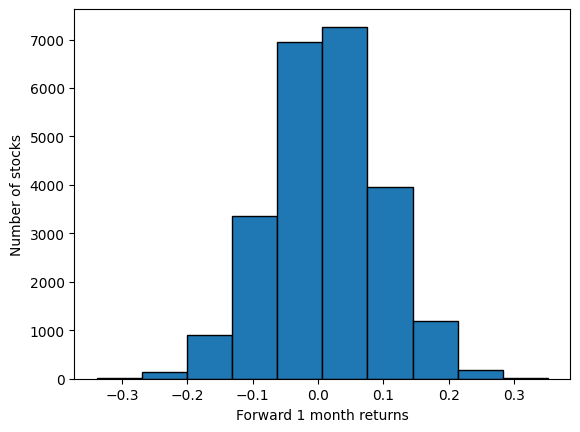

In [38]:
plt.hist(train["fwd_ret_1m"],bins=10,edgecolor="black")
plt.xlabel("Forward 1 month returns")
plt.ylabel("Number of stocks")

In [39]:
monthly_target=train.groupby("date")["fwd_ret_1m"].agg(["min","max","std","mean"])
print(monthly_target)

                 min       max       std      mean
date                                              
2013-01-31 -0.175185  0.205601  0.066274  0.019615
2013-02-28 -0.265208  0.200103  0.073434  0.007692
2013-03-31 -0.233649  0.196326  0.073609 -0.011012
2013-04-30 -0.205947  0.176202  0.069493 -0.002985
2013-05-31 -0.136165  0.230026  0.070237  0.054956
...              ...       ...       ...       ...
2022-08-31 -0.163525  0.183147  0.071799  0.011991
2022-09-30 -0.160232  0.190130  0.070345  0.036300
2022-10-31 -0.201431  0.206874  0.069730  0.041600
2022-11-30 -0.335210  0.081214  0.074494 -0.093802
2022-12-31 -0.219126  0.222858  0.069125  0.034033

[120 rows x 4 columns]


In [40]:
train["dataset"]="train"
test["dataset"]="test"

In [41]:
all_data=pd.concat([train,test],ignore_index=True)
all_data=all_data.sort_values(["date","ticker"])

In [42]:
all_data["ret_1m"]=all_data.groupby("ticker")["adj_close"].pct_change(1)
all_data["ret_3m"]=all_data.groupby("ticker")["adj_close"].pct_change(3)
all_data["ret_6m"]=all_data.groupby("ticker")["adj_close"].pct_change(6)
all_data["ret_12m"]=all_data.groupby("ticker")["adj_close"].pct_change(12)

In [43]:
all_data["price_1m_ago"]=all_data.groupby("ticker")["adj_close"].shift(1)
all_data["price_12m_ago"]=all_data.groupby("ticker")["adj_close"].shift(12)
all_data["mom_12_1"]=all_data["price_1m_ago"]/all_data["price_12m_ago"]-1

In [44]:
FUND_COLS = ["book_value", "eps_ttm", "revenue_ttm", "total_assets", "total_debt", "operating_income"]
all_data = all_data.sort_values(["ticker", "date"])
all_data[FUND_COLS] = (
    all_data.groupby("ticker")[FUND_COLS]
            .apply(lambda g: g.ffill(limit=4))
            .reset_index(level=0, drop=True)
)

In [45]:
all_data["book_to_market"]=all_data["book_value"]/all_data["market_cap"]

In [46]:
all_data["pe_ratio"]=all_data["adj_close"]/all_data["eps_ttm"]
all_data["pb_ratio"] = (
    all_data["adj_close"] *
    all_data["shares_out"] /
    all_data["book_value"]
)
all_data["ps_ratio"] = (
    all_data["market_cap"] /
    all_data["revenue_ttm"]
)
all_data["debt_to_assets"] = (
    all_data["total_debt"] /
    all_data["total_assets"]
)
all_data["debt_to_equity"] = (
    all_data["total_debt"] /
    all_data["book_value"]
)
all_data["roa"] = (
    all_data["operating_income"] /
    all_data["total_assets"]
)
all_data["operating_margin"] = (
    all_data["operating_income"] /
    all_data["revenue_ttm"]
)
all_data["log_market_cap"]=np.log1p(all_data["market_cap"])
all_data["earnings_yield"] = (
    all_data["eps_ttm"] /
    all_data["adj_close"]
)

In [47]:
features_col=["pb_ratio","ps_ratio","debt_to_assets","debt_to_equity","roa","operating_margin","log_market_cap","earnings_yield"]
all_data[features_col].describe()

,pb_ratio,ps_ratio,debt_to_assets,debt_to_equity,roa,operating_margin,log_market_cap,earnings_yield
count,28784.000000,28800.000000,28779.000000,28764.000000,28782.000000,28782.000000,28800.000000,28786.000000
mean,2.794415,1.479009,0.301345,1.060512,0.070190,0.122616,24.233438,0.063760
std,1.524449,0.803818,0.119922,0.834672,0.033846,0.085917,1.315606,0.035719
min,0.213076,0.285193,0.013938,0.025476,-0.084282,-0.170078,19.681985,-0.077096
25%,1.789967,0.987725,0.219736,0.531411,0.047595,0.070364,23.398579,0.039389
50%,2.479098,1.291068,0.299593,0.854091,0.070231,0.107903,24.342948,0.060236
75%,3.413714,1.714734,0.381871,1.363298,0.092363,0.154934,25.107407,0.084569
max,37.291980,9.614244,1.453725,19.934992,0.373606,0.852761,28.119247,0.332870


In [48]:
all_data[features_col].isnull().mean()*100

,0
pb_ratio,0.055556
ps_ratio,0.000000
debt_to_assets,0.072917
debt_to_equity,0.125000
roa,0.062500
operating_margin,0.062500
log_market_cap,0.000000
earnings_yield,0.048611


In [49]:
all_data.loc[all_data["debt_to_equity"].isna(),["total_debt","book_value","debt_to_equity"]].describe()

,total_debt,book_value,debt_to_equity
count,1.500000e+01,2.000000e+01,0.0
mean,7.857463e+09,6.774147e+09,NaN
std,5.459386e+09,6.506533e+09,NaN
min,8.838220e+08,4.288449e+08,NaN
25%,4.375482e+09,3.020110e+09,NaN
50%,7.160513e+09,5.908970e+09,NaN
75%,1.034771e+10,8.116900e+09,NaN
max,1.912389e+10,3.112453e+10,NaN


In [50]:
all_data.loc[all_data["debt_to_equity"].isna(),["total_debt","book_value","debt_to_equity"]].head(20)

,total_debt,book_value,debt_to_equity
22,NaN,1.279390e+09,NaN
35,NaN,9.892165e+09,NaN
39,NaN,4.042830e+09,NaN
239,NaN,4.042830e+09,NaN
47,2.096503e+09,NaN,NaN
55,1.619978e+09,NaN,NaN
61,8.838220e+08,NaN,NaN
64,1.912389e+10,NaN,NaN
67,1.077916e+10,NaN,NaN
70,7.160513e+09,NaN,NaN


In [51]:
all_data.loc[all_data["debt_to_equity"].isna(),["total_debt","book_value","debt_to_equity"]].isna().sum()

,0
total_debt,21
book_value,16
debt_to_equity,36


In [52]:
all_data[features_col].isin([np.inf,-np.inf]).sum()

,0
pb_ratio,0
ps_ratio,0
debt_to_assets,0
debt_to_equity,0
roa,0
operating_margin,0
log_market_cap,0
earnings_yield,0


In [53]:
all_data[features_col].isnull().mean()*100

,0
pb_ratio,0.055556
ps_ratio,0.000000
debt_to_assets,0.072917
debt_to_equity,0.125000
roa,0.062500
operating_margin,0.062500
log_market_cap,0.000000
earnings_yield,0.048611


In [54]:
all_data[features_col].quantile([0.01,0.05,0.50,0.95,0.99])

,pb_ratio,ps_ratio,debt_to_assets,debt_to_equity,roa,operating_margin,log_market_cap,earnings_yield
0.01,0.787230,0.540655,0.030201,0.088878,-0.008927,-0.013461,20.917034,-0.007453
0.05,1.099079,0.692914,0.104699,0.215787,0.013963,0.021091,21.953752,0.012154
0.50,2.479098,1.291068,0.299593,0.854091,0.070231,0.107903,24.342948,0.060236
0.95,5.469007,2.871738,0.497424,2.540057,0.124133,0.268912,26.280905,0.126798
0.99,7.897879,4.772833,0.583935,3.878652,0.149152,0.433875,27.241843,0.165050


In [55]:
def winsorize_series(x,lower=0.01,upper=0.99):
    low=x.quantile(lower)
    high=x.quantile(upper)
    return x.clip(lower=low,upper=high)

winsor_col = ["pb_ratio", "ps_ratio", "debt_to_assets", "debt_to_equity", "roa", "operating_margin", "earnings_yield"]

for col in winsor_col:
    all_data[col + "_w"] = all_data.groupby("date")[col].transform(winsorize_series)

In [56]:
all_data[["date","ticker","pb_ratio","pb_ratio_w"]].head(20)

,date,ticker,pb_ratio,pb_ratio_w
0,2013-01-31,SYN000,3.103405,3.103405
200,2013-02-28,SYN000,2.900997,2.900997
400,2013-03-31,SYN000,2.950225,2.950225
600,2013-04-30,SYN000,2.857441,2.857441
800,2013-05-31,SYN000,3.029311,3.029311
1000,2013-06-30,SYN000,3.067267,3.067267
1200,2013-07-31,SYN000,2.399392,2.399392
1400,2013-08-31,SYN000,2.226196,2.226196
1600,2013-09-30,SYN000,2.364224,2.364224
1800,2013-10-31,SYN000,3.215938,3.215938


In [57]:
(all_data["pb_ratio"]!=all_data["pb_ratio_w"])
all_data[["pb_ratio","pb_ratio_w"]].describe()

,pb_ratio,pb_ratio_w
count,28784.000000,28784.000000
mean,2.794415,2.771797
std,1.524449,1.376480
min,0.213076,0.555450
25%,1.789967,1.789967
50%,2.479098,2.479098
75%,3.413714,3.413714
max,37.291980,10.203668


In [58]:
all_data[["earnings_yield_w","earnings_yield"]].describe()

,earnings_yield_w,earnings_yield
count,28786.000000,28786.000000
mean,0.063634,0.063760
std,0.034525,0.035719
min,-0.018750,-0.077096
25%,0.039389,0.039389
50%,0.060236,0.060236
75%,0.084569,0.084569
max,0.230084,0.332870


In [59]:
def cross_sectional_zscore(x):
    return (x-x.mean())/x.std()

In [60]:
zscore_cols = [
    "earnings_yield_w",
    "pb_ratio_w",
    "ps_ratio_w",
    "debt_to_assets_w",
    "debt_to_equity_w",
    "roa_w",
    "operating_margin_w",
    "log_market_cap"
]

for col in zscore_cols:
    all_data[col+"_z"]=all_data.groupby("date")[col].transform(cross_sectional_zscore)
    print(all_data[col+"_z"].agg(["mean","std"]))

mean    1.579752e-17
std     9.975130e-01
Name: earnings_yield_w_z, dtype: float64
mean   -5.924481e-18
std     9.975128e-01
Name: pb_ratio_w_z, dtype: float64
mean    3.947460e-18
std     9.975142e-01
Name: ps_ratio_w_z, dtype: float64
mean    4.295995e-17
std     9.975124e-01
Name: debt_to_assets_w_z, dtype: float64
mean    2.964300e-18
std     9.975111e-01
Name: debt_to_equity_w_z, dtype: float64
mean   -3.949928e-18
std     9.975126e-01
Name: roa_w_z, dtype: float64
mean    1.382475e-17
std     9.975126e-01
Name: operating_margin_w_z, dtype: float64
mean    2.131628e-16
std     9.975142e-01
Name: log_market_cap_z, dtype: float64


In [61]:
all_data.groupby("date")["earnings_yield_w_z"].agg(["mean","std"])

,mean,std
date,,
2013-01-31,-2.539340e-16,1.0
2013-02-28,8.186493e-17,1.0
2013-03-31,1.998401e-17,1.0
2013-04-30,1.126876e-16,1.0
2013-05-31,2.367551e-16,1.0
...,...,...
2024-08-31,9.992007e-17,1.0
2024-09-30,-1.532108e-16,1.0
2024-10-31,9.769963e-17,1.0


In [62]:
all_data[zscore_cols].isnull().sum()

,0
earnings_yield_w,14
pb_ratio_w,16
ps_ratio_w,0
debt_to_assets_w,21
debt_to_equity_w,36
roa_w,18
operating_margin_w,18
log_market_cap,0


In [63]:
missing_cols=[
    "earnings_yield","pb_ratio","debt_to_assets","debt_to_equity","roa","operating_margin"
]

for col in missing_cols:
    all_data[col+"_missing"]=all_data[col].isna().astype(int)

In [64]:
all_data[zscore_cols]=all_data[zscore_cols].fillna(0)

In [65]:
[c for c in all_data.columns if "ret" in c.lower()]

['fwd_ret_1m', 'ret_1m', 'ret_3m', 'ret_6m', 'ret_12m']

In [66]:
ticker_example=all_data["ticker"].iloc[0]
all_data[all_data["ticker"]==ticker_example][["date","ticker","adj_close","fwd_ret_1m"]].tail(10)

,date,ticker,adj_close,fwd_ret_1m
26800,2024-03-31,SYN000,21.1123,NaN
27000,2024-04-30,SYN000,21.1422,NaN
27200,2024-05-31,SYN000,21.5685,NaN
27400,2024-06-30,SYN000,22.9240,NaN
27600,2024-07-31,SYN000,22.2908,NaN
27800,2024-08-31,SYN000,23.3742,NaN
28000,2024-09-30,SYN000,23.6280,NaN
28200,2024-10-31,SYN000,20.4636,NaN
28400,2024-11-30,SYN000,15.7878,NaN
28600,2024-12-31,SYN000,13.7797,NaN


In [67]:
train["fwd_ret_1m"].isna().sum()

np.int64(0)

In [68]:
all_data["fwd_ret_1m"].isna().sum()

np.int64(4800)

In [69]:
train_processed=all_data[all_data["dataset"]=="train"].copy()
test_processed=all_data[all_data["dataset"]=="test"].copy()

In [70]:
print(train_processed.shape)
print(test_processed.shape)

(24000, 53)
(4800, 53)


In [71]:
train["fwd_ret_1m"].isna().sum()



np.int64(0)

In [72]:
print(train_processed[features_col].isnull().sum())
print(test_processed[features_col].isnull().sum())

pb_ratio            16
ps_ratio             0
debt_to_assets      21
debt_to_equity      36
roa                 18
operating_margin    18
log_market_cap       0
earnings_yield      14
dtype: int64
pb_ratio            0
ps_ratio            0
debt_to_assets      0
debt_to_equity      0
roa                 0
operating_margin    0
log_market_cap      0
earnings_yield      0
dtype: int64


In [73]:
print(train_processed[features_col].isin([np.inf,-np.inf]).sum())
print(test_processed[features_col].isin([np.inf,-np.inf]).sum())
print(train_processed["date"].min())
print(train_processed["date"].max())
print(train_processed["date"].nunique())
print(test_processed["date"].nunique())

pb_ratio            0
ps_ratio            0
debt_to_assets      0
debt_to_equity      0
roa                 0
operating_margin    0
log_market_cap      0
earnings_yield      0
dtype: int64
pb_ratio            0
ps_ratio            0
debt_to_assets      0
debt_to_equity      0
roa                 0
operating_margin    0
log_market_cap      0
earnings_yield      0
dtype: int64
2013-01-31 00:00:00
2022-12-31 00:00:00
120
24


In [74]:
fundamental_cols = [
    "earnings_yield_w_z",
    "pb_ratio_w_z",
    "ps_ratio_w_z",
    "debt_to_assets_w_z",
    "debt_to_equity_w_z",
    "roa_w_z",
    "operating_margin_w_z",
    "log_market_cap_z"
]

momentum_cols = [
    "ret_1m",
    "ret_3m",
    "ret_6m",
    "ret_12m",
    "mom_12_1",
]

missing_flag_cols = [c + "_missing" for c in missing_cols]

feature_cols = momentum_cols + fundamental_cols + missing_flag_cols

In [75]:
print(train_processed[zscore_cols].isna().sum())
print(test_processed[zscore_cols].isna().sum())
train_processed[feature_cols].isnull().sum()

earnings_yield_w      0
pb_ratio_w            0
ps_ratio_w            0
debt_to_assets_w      0
debt_to_equity_w      0
roa_w                 0
operating_margin_w    0
log_market_cap        0
dtype: int64
earnings_yield_w      0
pb_ratio_w            0
ps_ratio_w            0
debt_to_assets_w      0
debt_to_equity_w      0
roa_w                 0
operating_margin_w    0
log_market_cap        0
dtype: int64


,0
ret_1m,200
ret_3m,600
ret_6m,1200
ret_12m,2400
mom_12_1,2400
earnings_yield_w_z,14
pb_ratio_w_z,16
ps_ratio_w_z,0
debt_to_assets_w_z,21
debt_to_equity_w_z,36


In [76]:
zscore_features = [
    "earnings_yield_w_z",
    "pb_ratio_w_z",
    "ps_ratio_w_z",
    "debt_to_assets_w_z",
    "debt_to_equity_w_z",
    "roa_w_z",
    "operating_margin_w_z",
    "log_market_cap_z"
]

all_data[zscore_features] = all_data[zscore_features].fillna(0)

In [77]:
all_data[zscore_features].isna().sum()

,0
earnings_yield_w_z,0
pb_ratio_w_z,0
ps_ratio_w_z,0
debt_to_assets_w_z,0
debt_to_equity_w_z,0
roa_w_z,0
operating_margin_w_z,0
log_market_cap_z,0


In [78]:
train_processed = all_data[all_data["dataset"] == "train"].copy()
test_processed = all_data[all_data["dataset"] == "test"].copy()

print(train_processed.shape)
print(test_processed.shape)

(24000, 53)
(4800, 53)


In [79]:
train_ml = train_processed.dropna(
    subset=["ret_1m", "ret_3m", "ret_6m", "ret_12m", "mom_12_1"]
).copy()

In [80]:
X_train = train_ml[feature_cols]
y_train = train_ml["fwd_ret_1m"]

X_test = test_processed[feature_cols].fillna(0)

In [81]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(21600, 19)
(21600,)
(4800, 19)


In [82]:
unique_months = np.sort(train_ml["date"].unique())
N_FOLDS = 5
val_block = max(len(unique_months) // (N_FOLDS + 1), 3)

folds = []
for k in range(1, N_FOLDS + 1):
    train_end = val_block * k
    val_start = train_end
    val_end = min(val_start + val_block, len(unique_months))
    if val_start >= len(unique_months) - 1:
        break
    folds.append((unique_months[:train_end], unique_months[val_start:val_end]))

for i, (tr_m, va_m) in enumerate(folds):
    print(f"fold {i}: train {pd.Timestamp(tr_m.min()).date()}->{pd.Timestamp(tr_m.max()).date()} "
          f"({len(tr_m)}m) | val {pd.Timestamp(va_m.min()).date()}->{pd.Timestamp(va_m.max()).date()} ({len(va_m)}m)")

fold 0: train 2014-01-31->2015-06-30 (18m) | val 2015-07-31->2016-12-31 (18m)
fold 1: train 2014-01-31->2016-12-31 (36m) | val 2017-01-31->2018-06-30 (18m)
fold 2: train 2014-01-31->2018-06-30 (54m) | val 2018-07-31->2019-12-31 (18m)
fold 3: train 2014-01-31->2019-12-31 (72m) | val 2020-01-31->2021-06-30 (18m)
fold 4: train 2014-01-31->2021-06-30 (90m) | val 2021-07-31->2022-12-31 (18m)


In [83]:
from scipy.stats import spearmanr

def monthly_rank_ic(dates, y_true, y_pred):
    d = pd.DataFrame({"date": dates, "y": y_true, "p": y_pred})
    ics = d.groupby("date").apply(lambda g: spearmanr(g["p"], g["y"]).correlation if len(g) > 5 else np.nan)
    return ics.dropna()

def decile_weights(g, top_q=0.90, bot_q=0.10):
    hi, lo = g["score"].quantile(top_q), g["score"].quantile(bot_q)
    longs, shorts = g["score"] >= hi, g["score"] <= lo
    w = pd.Series(0.0, index=g.index)
    if longs.sum() > 0:  w[longs]  =  1.0 / longs.sum()
    if shorts.sum() > 0: w[shorts] = -1.0 / shorts.sum()
    return w

def backtest(dates, tickers, scores, realized_ret, cost_bps=0.0010):
    df = pd.DataFrame({"date": dates, "ticker": tickers, "score": scores, "ret": realized_ret}).dropna(subset=["ret"])
    df["w"] = df.groupby("date", group_keys=False).apply(decile_weights)
    monthly_ret = df.groupby("date").apply(lambda g: (g["w"] * g["ret"]).sum())
    wide = df.pivot(index="date", columns="ticker", values="w").fillna(0.0).sort_index()
    turnover = wide.diff().abs().sum(axis=1)
    turnover.iloc[0] = wide.iloc[0].abs().sum()
    net_ret = (monthly_ret - turnover * cost_bps).dropna()
    sharpe = net_ret.mean() / net_ret.std(ddof=1) * np.sqrt(12) if net_ret.std(ddof=1) > 0 else np.nan
    ic = monthly_rank_ic(df["date"], df["ret"], df["score"])
    icir = ic.mean() / ic.std(ddof=1) if ic.std(ddof=1) > 0 else np.nan
    cum = (1 + net_ret).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {"sharpe": sharpe, "ic": ic.mean(), "icir": icir, "turnover": turnover.mean(),
            "max_dd": max_dd, "net_ret": net_ret}

In [84]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

candidate_models = {
    "Linear Regression": lambda: LinearRegression(),
    "Ridge":             lambda: Ridge(alpha=1.0),
    "Lasso":             lambda: Lasso(alpha=0.001),
    "Elastic Net":       lambda: ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Random Forest":     lambda: RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting": lambda: GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
}

cv_results = []
for name, builder in candidate_models.items():
    fold_scores, fold_dates, fold_tickers, fold_rets = [], [], [], []
    for tr_m, va_m in folds:
        tr_mask = train_ml["date"].isin(tr_m)
        va_mask = train_ml["date"].isin(va_m)
        model = builder()
        model.fit(train_ml.loc[tr_mask, feature_cols], train_ml.loc[tr_mask, "fwd_ret_1m"])
        pred = model.predict(train_ml.loc[va_mask, feature_cols])
        fold_scores.append(pred)
        fold_dates.append(train_ml.loc[va_mask, "date"].values)
        fold_tickers.append(train_ml.loc[va_mask, "ticker"].values)
        fold_rets.append(train_ml.loc[va_mask, "fwd_ret_1m"].values)
    res = backtest(np.concatenate(fold_dates), np.concatenate(fold_tickers),
                    np.concatenate(fold_scores), np.concatenate(fold_rets))
    cv_results.append({"Model": name, "Net Sharpe": res["sharpe"], "Rank IC": res["ic"],
                        "ICIR": res["icir"], "Turnover": res["turnover"], "Max Drawdown": res["max_dd"]})

cv_results = pd.DataFrame(cv_results).sort_values("Net Sharpe", ascending=False).reset_index(drop=True)
print(cv_results)

/tmp/ipykernel_2206/568979253.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["w"] = df.groupby("date", group_keys=False).apply(decile_weights)
/tmp/ipykernel_2206/568979253.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ret = df.groupby("date").apply(lambda g: (g["w"] * g["ret"]).sum())
/tmp/ipykernel_2206/568979253.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

               Model  Net Sharpe   Rank IC      ICIR  Turnover  Max Drawdown
0              Lasso    0.840271  0.035029  0.530779  0.920000     -0.142821
1        Elastic Net    0.557070  0.027551  0.412351  1.384444     -0.133149
2      Random Forest    0.450580  0.005494  0.067005  2.893333     -0.179115
3  Gradient Boosting    0.437232  0.010619  0.134049  2.813333     -0.099548
4  Linear Regression    0.059863  0.006199  0.080095  2.998889     -0.301388
5              Ridge    0.010022  0.008526  0.109567  2.925556     -0.325397


/tmp/ipykernel_2206/568979253.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["w"] = df.groupby("date", group_keys=False).apply(decile_weights)
/tmp/ipykernel_2206/568979253.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ret = df.groupby("date").apply(lambda g: (g["w"] * g["ret"]).sum())
/tmp/ipykernel_2206/568979253.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

In [85]:
bench_res = backtest(train_ml["date"], train_ml["ticker"], train_ml["mom_12_1"], train_ml["fwd_ret_1m"])
print(f"12-1 Momentum benchmark: Net Sharpe {bench_res['sharpe']:.3f}  "
      f"Rank IC {bench_res['ic']:.4f}  ICIR {bench_res['icir']:.3f}")

12-1 Momentum benchmark: Net Sharpe 1.895  Rank IC 0.0458  ICIR 0.585


/tmp/ipykernel_2206/568979253.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["w"] = df.groupby("date", group_keys=False).apply(decile_weights)
/tmp/ipykernel_2206/568979253.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_ret = df.groupby("date").apply(lambda g: (g["w"] * g["ret"]).sum())
/tmp/ipykernel_2206/568979253.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

In [86]:
best_name = cv_results.iloc[0]["Model"]
print("Selected model:", best_name)

final_model = candidate_models[best_name]()
final_model.fit(train_ml[feature_cols], train_ml["fwd_ret_1m"])

final_predictions = final_model.predict(X_test)

Selected model: Lasso


In [87]:
final_submit = pd.DataFrame({
    "date": test_processed["date_raw"],   # untouched original string -> guaranteed to match test.csv exactly
    "ticker": test_processed["ticker"],
    "score": final_predictions,
})

assert final_submit.columns.tolist() == ["date", "ticker", "score"]
assert final_submit["score"].apply(np.isfinite).all()
assert not final_submit.duplicated(subset=["date", "ticker"]).any()

final_submit.to_csv("final_submit.csv", index=False)
print(final_submit.shape)
final_submit.head()

(4800, 3)


,date,ticker,score
24000,2023-01-31,SYN000,0.011704
24200,2023-02-28,SYN000,0.011948
24400,2023-03-31,SYN000,0.012043
24600,2023-04-30,SYN000,0.013472
24800,2023-05-31,SYN000,0.013467


In [88]:
!python validate.py final_submit.csv

PASS: 4800 rows, 24 dates, 200 tickers. Submission is well-formed.
